# Environment Setup & Imports

In [3]:
# ============================================================
# Environment Setup & Core Imports
# ------------------------------------------------------------
# This cell imports all required libraries and sets up the
# computation device (CPU or GPU).
# ============================================================
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Download & Prepare Food-101 Dataset



In [2]:
# ============================================================
# Dataset Download: Food-101
# ------------------------------------------------------------
# This cell downloads and extracts the Food-101 dataset
# using torchvision utilities and verifies its directory
# structure.
# ============================================================
import os
from torchvision import datasets

# Create data directory
DATA_ROOT = "/content/data"
os.makedirs(DATA_ROOT, exist_ok=True)

# Download and extract Food-101
food101_download = datasets.Food101(root=DATA_ROOT, download=True)
print("Downloaded to:", food101_download.root)

# Path will be something like: /content/data/food-101
FOOD101_ROOT = os.path.join(DATA_ROOT, "food-101")
print("Food-101 root:", FOOD101_ROOT)

# Show contents to confirm structure
print("Directory structure:", os.listdir(FOOD101_ROOT))



100%|██████████| 5.00G/5.00G [05:42<00:00, 14.6MB/s]


Downloaded to: /content/data
Food-101 root: /content/data/food-101
Directory structure: ['license_agreement.txt', 'meta', 'images', 'README.txt']


# Load Class Labels

In [7]:
# ============================================================
# Class Label Extraction
# ------------------------------------------------------------
# This cell extracts the list of food categories (classes)
# from the Food-101 image directory.
# ============================================================

classes_dir = os.path.join(FOOD101_ROOT, "images")
classes = sorted([d for d in os.listdir(classes_dir) if os.path.isdir(os.path.join(classes_dir, d))])
print("Num classes:", len(classes))
print("First 10:", classes[:10])

Num classes: 101
First 10: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


# Upload Nutrition Metadata (Manual Step)

In [8]:
# ============================================================
# Upload Nutrition Metadata File
# ------------------------------------------------------------
# This cell allows the user to upload an external CSV file
# containing nutritional information per food class.
#
# Expected: a CSV file mapping food names to nutrition values
# (e.g., calories, protein, fat, carbohydrates, etc.).
# ============================================================
from google.colab import files
files.upload()

Saving nutrition.csv to nutrition.csv


{'nutrition.csv': b'"label","weight","calories","protein","carbohydrates","fats","fiber","sugars","sodium"\r\n"apple_pie","80","240","2","36","10","2","16","120"\r\n"apple_pie","100","300","3","45","12","2","20","150"\r\n"apple_pie","120","360","4","54","14","3","24","180"\r\n"apple_pie","150","450","5","68","18","3","30","225"\r\n"apple_pie","200","600","6","90","24","4","40","300"\r\n"baby_back_ribs","150","540","38","15","33","1","12","720"\r\n"baby_back_ribs","200","720","50","20","44","2","16","960"\r\n"baby_back_ribs","250","900","63","25","55","2","20","1200"\r\n"baby_back_ribs","300","1080","75","30","66","3","24","1440"\r\n"baby_back_ribs","350","1260","88","35","77","3","28","1680"\r\n"baklava","50","165","3","20","8","1","13","60"\r\n"baklava","70","231","4","28","11","1","18","84"\r\n"baklava","100","330","6","40","16","2","25","120"\r\n"baklava","120","396","7","48","19","2","30","144"\r\n"baklava","150","495","9","60","24","3","38","180"\r\n"beef_carpaccio","100","200","2

# Load & Clean Nutrition Metadata (nutrition.csv)

In [9]:
NUTR_PATH = "/content/nutrition.csv"

nutr_df = pd.read_csv(NUTR_PATH)

# normalize label formatting
nutr_df["label"] = nutr_df["label"].astype(str).str.strip().str.lower().str.replace(" ", "_")

# choose targets (exclude fiber + do not predict weight)
RAW_TARGETS = ["calories", "protein", "carbohydrates", "fats", "sugars", "sodium"]

# convert "per portion weight" -> per 100g
for c in RAW_TARGETS:
    nutr_df[c] = nutr_df[c].astype(float) / nutr_df["weight"].astype(float) * 100.0

# average multiple rows per class
nutr_per100 = nutr_df.groupby("label")[RAW_TARGETS].mean().reset_index()

# rename for convenience
nutr_per100 = nutr_per100.rename(columns={"label": "class_name", "carbohydrates": "carbs", "fats": "fat"})
TARGET_COLS = ["calories", "protein", "fat", "carbs", "sugars", "sodium"]

import difflib

# --- 1) Show what nutrition labels exist (for debugging) ---
nutr_labels = set(nutr_per100["class_name"].tolist())

missing = sorted(list(set(classes) - nutr_labels))
print("Missing before alias:", missing)

# --- 2) Aliases: Food-101 -> nutrition label ---
# These 3 almost always appear without underscores or with slightly different wording in the Kaggle file
ALIASES = {
    "cup_cakes": "cupcakes",
    "grilled_cheese_sandwich": "grilled cheese sandwich",
    "lobster_roll_sandwich": "lobster roll",
}

# Try to map aliases to something that actually exists
resolved_aliases = {}
for k, v in ALIASES.items():
    if v in nutr_labels:
        resolved_aliases[k] = v
    else:
        # If exact alias not found, try closest match
        close = difflib.get_close_matches(v, nutr_labels, n=3, cutoff=0.6)
        print(f"Alias '{k}' -> '{v}' not found. Closest:", close)
        if close:
            resolved_aliases[k] = close[0]

print("Resolved aliases:", resolved_aliases)

# Apply aliases by duplicating rows under Food-101 class_name
for food101_name, nutr_name in resolved_aliases.items():
    row = nutr_per100[nutr_per100["class_name"] == nutr_name]
    if len(row) == 1:
        new_row = row.copy()
        new_row.loc[:, "class_name"] = food101_name
        nutr_per100 = pd.concat([nutr_per100, new_row], ignore_index=True)

# refresh label set
nutr_labels = set(nutr_per100["class_name"].tolist())
missing = sorted(list(set(classes) - nutr_labels))
print("Missing after alias:", missing)


nutrition_mapping = {
    row["class_name"]: torch.tensor([row[c] for c in TARGET_COLS], dtype=torch.float32)
    for _, row in nutr_per100.iterrows()
}

# sanity check
missing = sorted(list(set(classes) - set(nutrition_mapping.keys())))
print("Nutrition dims:", len(TARGET_COLS))
print("Missing classes:", len(missing))
if len(missing) > 0:
    print("Missing list:", missing[:30])

# normalization stats
Y = torch.stack([nutrition_mapping[c] for c in classes], dim=0)  # in Food-101 class order
y_mean = Y.mean(dim=0)
y_std  = Y.std(dim=0).clamp(min=1e-6)

print("Example pizza per100g:", nutrition_mapping.get("pizza"))
print("y_mean:", y_mean)
print("y_std :", y_std)

Missing before alias: ['cup_cakes', 'grilled_cheese_sandwich', 'lobster_roll_sandwich']
Alias 'grilled_cheese_sandwich' -> 'grilled cheese sandwich' not found. Closest: ['grilled_cheese']
Alias 'lobster_roll_sandwich' -> 'lobster roll' not found. Closest: ['lobster_roll']
Resolved aliases: {'cup_cakes': 'cupcakes', 'grilled_cheese_sandwich': 'grilled_cheese', 'lobster_roll_sandwich': 'lobster_roll'}
Missing after alias: []
Nutrition dims: 6
Missing classes: 0
Example pizza per100g: tensor([250.0000,  10.0000,  10.0000,  30.0000,   2.5276, 400.0000])
y_mean: tensor([227.6625,   9.2836,  11.4458,  20.4208,   7.0522, 256.5995])
y_std : tensor([ 85.9010,   5.7143,   6.4311,  14.4360,   9.5748, 103.2560])


# Define Image Transforms (Train vs Test)

In [10]:
# ============================================================
# Image Preprocessing (Transforms)
# ------------------------------------------------------------
# Train transform includes mild augmentation (horizontal flip)
# to improve generalization.
# Test transform avoids random augmentation for stable evaluation.
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),          # ResNet standard input size
    transforms.RandomHorizontalFlip(),      # simple augmentation
    transforms.ToTensor(),                  # convert PIL -> torch tensor
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])



# Custom Dataset: Food101WithNutrition (Multi-task labels)

In [11]:
# ============================================================
# Custom Dataset: Food101 + Nutrition Targets
# ------------------------------------------------------------
# Each item returns:
# - image tensor
# - class label (int)
# - nutrition vector (normalized), aligned with class label
#
# This enables multi-task learning:
# - classification head predicts class
# - regression head predicts nutrition profile (per 100g)
# ============================================================

class Food101WithNutrition(Dataset):
    """
    Food-101 dataset wrapper that returns both:
      (1) food class label
      (2) nutrition regression target for that class

    Nutrition targets are standardized (normalized using y_mean/y_std)
    for stable multi-output regression.
    """
    def __init__(self, root, split="train", transform=None, nutrition_mapping=None, y_mean=None, y_std=None):
        self.root = root
        self.split = split
        self.transform = transform
        self.nutrition_mapping = nutrition_mapping
        self.y_mean = y_mean
        self.y_std = y_std

        # Ensure required inputs are provided
        assert self.nutrition_mapping is not None, "nutrition_mapping is required"
        assert self.y_mean is not None and self.y_std is not None, "y_mean/y_std required"

        # Build class index mapping from dataset folder names
        self.classes = sorted([d for d in os.listdir(os.path.join(root, "images"))
                               if os.path.isdir(os.path.join(root, "images", d))])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        # Food-101 provides predefined train/test splits in meta/*.txt
        meta_dir = os.path.join(root, "meta")
        txt_path = os.path.join(meta_dir, f"{split}.txt")

        # Load image relative paths from train.txt / test.txt
        with open(txt_path, "r") as f:
            rel_paths = [line.strip() for line in f.readlines()]

        # Build list of (absolute_image_path, label_index)
        self.samples = []
        for rel in rel_paths:
            cls = rel.split("/")[0]
            img_path = os.path.join(root, "images", rel + ".jpg")
            self.samples.append((img_path, self.class_to_idx[cls]))

        # Infer nutrition dimensionality from mapping tensor shape
        any_vec = next(iter(self.nutrition_mapping.values()))
        self.nutrition_dim = int(any_vec.shape[0])

    def __len__(self):
        # Number of images in the split
        return len(self.samples)

    def __getitem__(self, idx):
        # Load image + label
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        # Apply preprocessing/augmentation
        if self.transform:
            image = self.transform(image)

        # Convert class label index -> class name string
        class_name = self.classes[label]

        # Lookup nutrition target vector for this class (per 100g, unnormalized)
        nutr = self.nutrition_mapping[class_name]

        # Normalize regression target for stable training
        nutr = (nutr - self.y_mean) / self.y_std

        return image, label, nutr



# Create DataLoaders (Train/Test)

In [12]:
# ============================================================
# DataLoaders
# ------------------------------------------------------------
# Train loader:
# - shuffle=True for stochastic gradient updates
# Test loader:
# - shuffle=False for deterministic evaluation ordering
# ============================================================

train_ds = Food101WithNutrition(
    FOOD101_ROOT, split="train",
    transform=train_transform,
    nutrition_mapping=nutrition_mapping,
    y_mean=y_mean, y_std=y_std
)

test_ds = Food101WithNutrition(
    FOOD101_ROOT, split="test",
    transform=test_transform,
    nutrition_mapping=nutrition_mapping,
    y_mean=y_mean, y_std=y_std
)

# Batch size differs for train vs test (test can be larger for speed)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
nutrition_dim = train_ds.nutrition_dim

print("num_classes:", num_classes, "nutrition_dim:", nutrition_dim)



num_classes: 101 nutrition_dim: 6


# Multi-Task Model Definition (ResNet18 Backbone)

In [13]:
# ============================================================
# Multi-Task Model: ResNet18 Backbone
# ------------------------------------------------------------
# The model performs two tasks simultaneously:
# 1) Image classification (Food-101, 101 classes)
# 2) Nutrition prediction (multi-output regression)
#
# A shared ResNet18 backbone extracts visual features,
# followed by two task-specific linear heads.
# ============================================================

import torchvision.models as models
import torch.nn as nn

class MultiTaskResNet(nn.Module):
    """
    Multi-task neural network with a shared ResNet18 backbone.

    Outputs:
    - logits: raw classification scores (used with CrossEntropyLoss)
    - nutr: normalized nutrition predictions (used with MSELoss)
    """
    def __init__(self, num_classes=101, nutrition_dim=6):
        super().__init__()

        # Load pretrained ResNet18 and remove its final classification layer
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.resnet.fc = nn.Identity()  # output is a 512-dim feature vector
        self.backbone_out = 512

        # Task-specific heads
        # Classification head outputs raw logits (softmax applied inside CrossEntropyLoss)
        self.classifier = nn.Linear(self.backbone_out, num_classes)

        # Regression head outputs continuous values (no activation for MSE loss)
        self.regressor  = nn.Linear(self.backbone_out, nutrition_dim)

    def backbone(self, x):
        # Shared feature extractor
        return self.resnet(x)

    def forward(self, x):
        # Forward pass through backbone and both heads
        feat = self.backbone(x)
        logits = self.classifier(feat)
        nutr = self.regressor(feat)
        return logits, nutr

# Instantiate model and move to device (CPU/GPU)
model = MultiTaskResNet(num_classes=num_classes, nutrition_dim=nutrition_dim).to(device)

# Print number of trainable parameter tensors (sanity check)
print(sum(p.requires_grad for p in model.parameters()), "params tensors trainable")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


64 params tensors trainable


# Loss Functions, Optimizer & Training Hyperparameters

In [14]:
# ============================================================
# Loss Functions, Optimizer & Hyperparameters
# ------------------------------------------------------------
# - Classification loss: CrossEntropyLoss (applies LogSoftmax internally)
# - Regression loss: Mean Squared Error (MSE)
# - Total loss: weighted sum of classification and regression losses
# ============================================================

import torch.optim as optim

# Classification loss (expects raw logits)
criterion_cls = nn.CrossEntropyLoss()

# Regression loss (continuous normalized targets)
criterion_reg = nn.MSELoss()

# Weight applied to regression loss to balance multi-task learning
lambda_reg = 0.15  # slight priority to classification task

# Adam optimizer with weight decay for regularization
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Number of training epochs
EPOCHS = 6


# Training Loop and Evaluation Loop

In [4]:
# ============================================================
# Training Function (One Epoch)
# ------------------------------------------------------------
# Performs one full pass over the training dataset:
# - Forward pass
# - Loss computation (classification + regression)
# - Backpropagation and parameter update
# - Tracks loss components and classification accuracy
# ============================================================

def train_one_epoch(model, loader):
    model.train()

    total_loss = 0.0
    total_cls_loss = 0.0
    total_reg_loss = 0.0
    correct = 0
    total = 0

    for images, labels, nutr in loader:
        # Move batch to device
        images = images.to(device)
        labels = labels.to(device)
        nutr   = nutr.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        logits, nutr_pred = model(images)

        # Compute task-specific losses
        cls_loss = criterion_cls(logits, labels)
        reg_loss = criterion_reg(nutr_pred, nutr)

        # Combined multi-task loss
        loss = cls_loss + lambda_reg * reg_loss

        # Backpropagation and optimization step
        loss.backward()
        optimizer.step()

        # Accumulate losses (scaled by batch size)
        total_loss += loss.item() * images.size(0)
        total_cls_loss += cls_loss.item() * images.size(0)
        total_reg_loss += reg_loss.item() * images.size(0)

        # Compute classification accuracy
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # Return average losses and accuracy
    return (total_loss/total, total_cls_loss/total, total_reg_loss/total, correct/total)


# ============================================================
# Evaluation Function (One Epoch)
# ------------------------------------------------------------
# Evaluates model performance on validation/test data.
# Gradients are disabled for efficiency and correctness.
# ============================================================

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()

    total_loss = 0.0
    total_cls_loss = 0.0
    total_reg_loss = 0.0
    correct = 0
    total = 0

    for images, labels, nutr in loader:
        # Move batch to device
        images = images.to(device)
        labels = labels.to(device)
        nutr   = nutr.to(device)

        # Forward pass
        logits, nutr_pred = model(images)

        # Compute losses
        cls_loss = criterion_cls(logits, labels)
        reg_loss = criterion_reg(nutr_pred, nutr)
        loss = cls_loss + lambda_reg * reg_loss

        # Accumulate losses
        total_loss += loss.item() * images.size(0)
        total_cls_loss += cls_loss.item() * images.size(0)
        total_reg_loss += reg_loss.item() * images.size(0)

        # Classification accuracy
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return (total_loss/total, total_cls_loss/total, total_reg_loss/total, correct/total)

# Training Loop Over Epochs

In [16]:
history = []

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_cls, tr_reg, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_cls, te_reg, te_acc = eval_one_epoch(model, test_loader)

    history.append((epoch, tr_loss, tr_cls, tr_reg, tr_acc, te_loss, te_cls, te_reg, te_acc))
    print(f"Epoch {epoch:02d} | "
          f"Train loss {tr_loss:.4f} (cls {tr_cls:.4f}, reg {tr_reg:.4f}) acc {tr_acc:.4f} | "
          f"Test  loss {te_loss:.4f} (cls {te_cls:.4f}, reg {te_reg:.4f}) acc {te_acc:.4f}")

Epoch 01 | Train loss 1.9969 (cls 1.9093, reg 0.5844) acc 0.5456 | Test  loss 1.1533 (cls 1.0892, reg 0.4274) acc 0.7116
Epoch 02 | Train loss 1.1910 (cls 1.1236, reg 0.4488) acc 0.7083 | Test  loss 0.9633 (cls 0.9049, reg 0.3889) acc 0.7514
Epoch 03 | Train loss 0.9058 (cls 0.8455, reg 0.4023) acc 0.7756 | Test  loss 0.9435 (cls 0.8873, reg 0.3753) acc 0.7561
Epoch 04 | Train loss 0.7075 (cls 0.6520, reg 0.3703) acc 0.8239 | Test  loss 0.9429 (cls 0.8874, reg 0.3699) acc 0.7602
Epoch 05 | Train loss 0.5530 (cls 0.5010, reg 0.3464) acc 0.8653 | Test  loss 0.9508 (cls 0.8937, reg 0.3806) acc 0.7604
Epoch 06 | Train loss 0.4454 (cls 0.3965, reg 0.3265) acc 0.8913 | Test  loss 0.9700 (cls 0.9156, reg 0.3627) acc 0.7621


# Select Best Epoch Based on Test Accuracy

In [17]:
import numpy as np

# history rows: (epoch, tr_loss, tr_cls, tr_reg, tr_acc, te_loss, te_cls, te_reg, te_acc)
best_row = max(history, key=lambda x: x[-1])
best_epoch, tr_loss, tr_cls, tr_reg, tr_acc, te_loss, te_cls, te_reg, te_acc = best_row

print("Best epoch:", best_epoch)
print(f"Best test acc: {te_acc:.4f}")
print(f"Best test loss: {te_loss:.4f} (cls {te_cls:.4f}, reg {te_reg:.4f})")


Best epoch: 6
Best test acc: 0.7621
Best test loss: 0.9700 (cls 0.9156, reg 0.3627)


# Save Trained Model & Metadata

In [18]:
import torch, json

SAVE_PATH = "food101_multitask_resnet18.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "y_mean": y_mean.cpu(),
    "y_std": y_std.cpu(),
    "classes": classes,
    "history": history,
}, SAVE_PATH)

print("Saved:", SAVE_PATH)


Saved: food101_multitask_resnet18.pt


# Training Curves (Accuracy & Loss)

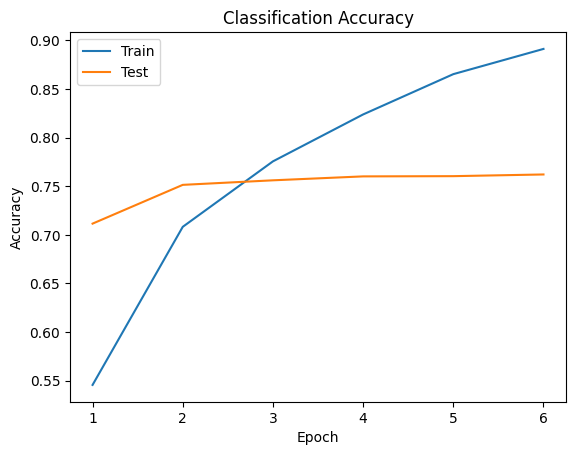

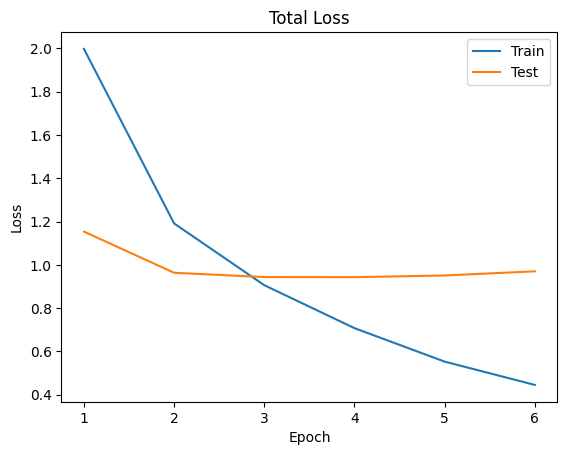

In [19]:
# ============================================================
# Training Curves Visualization
# ------------------------------------------------------------
# Plots training vs test performance over epochs to:
# - inspect convergence
# - detect overfitting
# ============================================================

import matplotlib.pyplot as plt

epochs = [r[0] for r in history]

# Classification accuracy curves
tr_accs = [r[4] for r in history]
te_accs = [r[8] for r in history]

# Total loss curves (classification + regression)
tr_losses = [r[1] for r in history]
te_losses = [r[5] for r in history]

plt.figure()
plt.plot(epochs, tr_accs)
plt.plot(epochs, te_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"])
plt.title("Classification Accuracy")
plt.show()

plt.figure()
plt.plot(epochs, tr_losses)
plt.plot(epochs, te_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.title("Total Loss")
plt.show()



# Collect Full Test-Set Outputs

In [35]:
# ============================================================
# Collect Model Outputs on Full Test Set
# ------------------------------------------------------------
# Runs the trained model over the entire test set and stores:
# - classification logits
# - ground-truth labels
# - predicted nutrition vectors
# - ground-truth nutrition vectors
#
# Used for detailed evaluation metrics.
# ============================================================

import torch
import numpy as np

@torch.no_grad()
def collect_test_outputs(model, loader, device):
    model.eval()

    all_logits = []
    all_labels = []
    all_nutr_pred = []
    all_nutr_gt = []

    for images, labels, nutr_gt in loader:
        images = images.to(device)
        labels = labels.to(device)
        nutr_gt = nutr_gt.to(device)

        logits, nutr_pred = model(images)

        # Store outputs on CPU for metric computation
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())
        all_nutr_pred.append(nutr_pred.cpu())
        all_nutr_gt.append(nutr_gt.cpu())

    # Concatenate all batches
    all_logits = torch.cat(all_logits, dim=0)        # (N, C)
    all_labels = torch.cat(all_labels, dim=0)        # (N,)
    all_nutr_pred = torch.cat(all_nutr_pred, dim=0)  # (N, D), normalized
    all_nutr_gt = torch.cat(all_nutr_gt, dim=0)      # (N, D), normalized

    return all_logits, all_labels, all_nutr_pred, all_nutr_gt

# Run collection on test set
test_logits, test_labels, nutr_pred_norm, nutr_gt_norm = collect_test_outputs(
    model, test_loader, device
)

print(
    "Collected:",
    test_logits.shape,
    test_labels.shape,
    nutr_pred_norm.shape,
    nutr_gt_norm.shape
)



Collected: torch.Size([25250, 101]) torch.Size([25250]) torch.Size([25250, 6]) torch.Size([25250, 6])


# Nutrition De-normalization Utilities

In [20]:
# ============================================================
# Nutrition Utility Functions
# ------------------------------------------------------------
# Helper functions to:
# - convert normalized nutrition outputs back to real units
# - format nutrition vectors for readable display
# ============================================================

import torch

TARGET_COLS = ["calories", "protein", "fat", "carbs", "sugars", "sodium"]

def unnormalize_nutr(nutr_norm: torch.Tensor, y_mean: torch.Tensor, y_std: torch.Tensor):
    """
    Converts normalized nutrition vectors back to original units (per 100g).
    """
    return nutr_norm * y_std + y_mean

def format_nutr(vec, cols=TARGET_COLS):
    """
    Formats a nutrition tensor as a readable dictionary.
    """
    vec = vec.detach().cpu().numpy().tolist()
    return {c: float(v) for c, v in zip(cols, vec)}



# Classification Evaluation Metrics

Top-1 Accuracy: 0.7621
Top-5 Accuracy: 0.9341

Worst-10 classes (by per-class accuracy):
steak                     acc=0.396  support=250
pork_chop                 acc=0.412  support=250
apple_pie                 acc=0.436  support=250
bread_pudding             acc=0.448  support=250
ceviche                   acc=0.544  support=250
foie_gras                 acc=0.580  support=250
breakfast_burrito         acc=0.584  support=250
bruschetta                acc=0.584  support=250
huevos_rancheros          acc=0.584  support=250
clam_chowder              acc=0.588  support=250


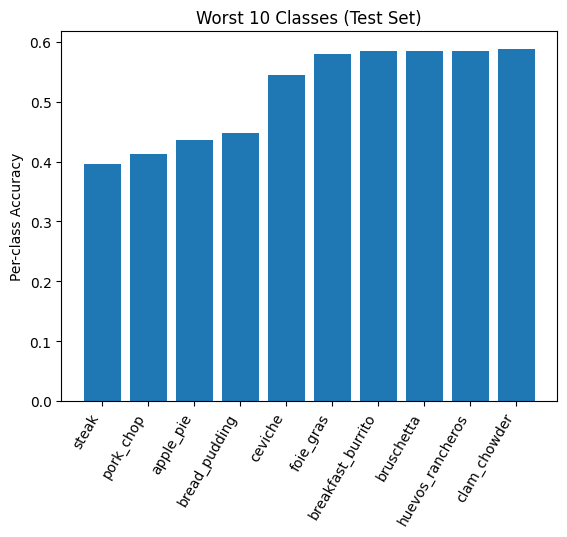


Top confusion pairs (true -> predicted):
steak -> filet_mignon : 84
clam_chowder -> lobster_bisque : 61
pork_chop -> filet_mignon : 44
chocolate_cake -> chocolate_mousse : 41
tuna_tartare -> beef_tartare : 36
hamburger -> pulled_pork_sandwich : 33
poutine -> french_fries : 29
scallops -> crab_cakes : 27
spaghetti_carbonara -> spaghetti_bolognese : 27
falafel -> crab_cakes : 27


In [38]:
# ============================================================
# Classification Evaluation
# ------------------------------------------------------------
# Computes:
# - Top-1 accuracy
# - Top-5 accuracy
# - Per-class accuracy
# - Most confused class pairs
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Top-1 accuracy
top1_pred = test_logits.argmax(dim=1)
top1_acc = (top1_pred == test_labels).float().mean().item()

# Top-5 accuracy (Food-101 standard metric)
top5_pred = torch.topk(test_logits, k=5, dim=1).indices
top5_acc = (top5_pred == test_labels.unsqueeze(1)).any(dim=1).float().mean().item()

print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

# Confusion matrix (101 x 101)
cm = confusion_matrix(
    test_labels.numpy(),
    top1_pred.numpy(),
    labels=np.arange(len(classes))
)

# Per-class accuracy
row_sums = cm.sum(axis=1)
diag = np.diag(cm)
per_class_acc = np.divide(
    diag, row_sums,
    out=np.zeros_like(diag, dtype=float),
    where=row_sums != 0
)

# Identify worst-performing classes
worst_idx = np.argsort(per_class_acc)[:10]
print("\nWorst-10 classes (by per-class accuracy):")
for i in worst_idx:
    print(f"{classes[i]:<25} acc={per_class_acc[i]:.3f}  support={row_sums[i]}")

# Plot worst-class accuracies
plt.figure()
plt.bar([classes[i] for i in worst_idx], [per_class_acc[i] for i in worst_idx])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Per-class Accuracy")
plt.title("Worst 10 Classes (Test Set)")
plt.show()

# Most confused class pairs (off-diagonal entries)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat = cm_off.flatten()
top_pairs = np.argsort(flat)[-10:][::-1]

print("\nTop confusion pairs (true -> predicted):")
for idx in top_pairs:
    t = idx // cm.shape[1]
    p = idx % cm.shape[1]
    count = cm_off[t, p]
    if count > 0:
        print(f"{classes[t]} -> {classes[p]} : {count}")


# Nutrition Regression Evaluation


Regression MAE (per nutrient, per 100g):
calories  : 35.290
protein   : 2.504
fat       : 2.873
carbs     : 6.398
sugars    : 3.501
sodium    : 54.150

Regression R^2 (per nutrient):
calories  : 0.698
protein   : 0.623
fat       : 0.583
carbs     : 0.657
sugars    : 0.725
sodium    : 0.516


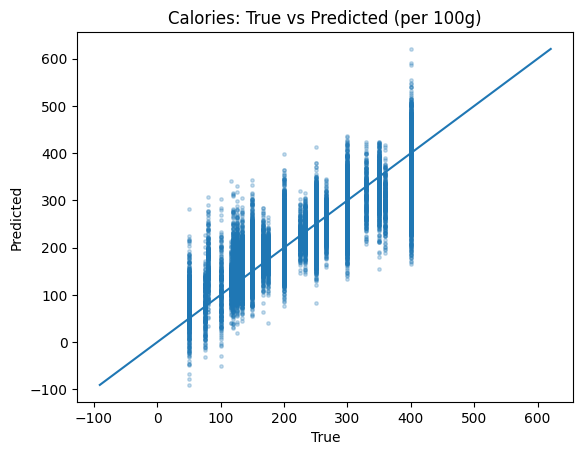

In [37]:
# ============================================================
# Nutrition Regression Evaluation
# ------------------------------------------------------------
# Reports:
# - Mean Absolute Error (MAE) per nutrient
# - R^2 score per nutrient
# - Scatter plot of true vs predicted calories
#
# All values are reported in real units (per 100g).
# ============================================================


from sklearn.metrics import r2_score

# Unnormalize to real units
nutr_pred = unnormalize_nutr(nutr_pred_norm, y_mean.cpu(), y_std.cpu()).numpy()  # (N, D)
nutr_gt   = unnormalize_nutr(nutr_gt_norm,   y_mean.cpu(), y_std.cpu()).numpy()  # (N, D)

# MAE per nutrient
mae = np.mean(np.abs(nutr_pred - nutr_gt), axis=0)

print("\nRegression MAE (per nutrient, per 100g):")
for c, v in zip(TARGET_COLS, mae):
    print(f"{c:<10}: {v:.3f}")

# R^2 per nutrient
print("\nRegression R^2 (per nutrient):")
for j, c in enumerate(TARGET_COLS):
    r2 = r2_score(nutr_gt[:, j], nutr_pred[:, j])
    print(f"{c:<10}: {r2:.3f}")

# Scatter plot: true vs predicted calories (and one more nutrient if you want)
def scatter_true_vs_pred(x_true, x_pred, title):
    plt.figure()
    plt.scatter(x_true, x_pred, s=6, alpha=0.25)
    mn = min(x_true.min(), x_pred.min())
    mx = max(x_true.max(), x_pred.max())
    plt.plot([mn, mx], [mn, mx])  # y=x reference
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

scatter_true_vs_pred(nutr_gt[:, 0], nutr_pred[:, 0], "Calories: True vs Predicted (per 100g)")
# Example extra:
# scatter_true_vs_pred(nutr_gt[:, 1], nutr_pred[:, 1], "Protein: True vs Predicted (per 100g)")


# Qualitative Results: Random, Diverse Test Examples

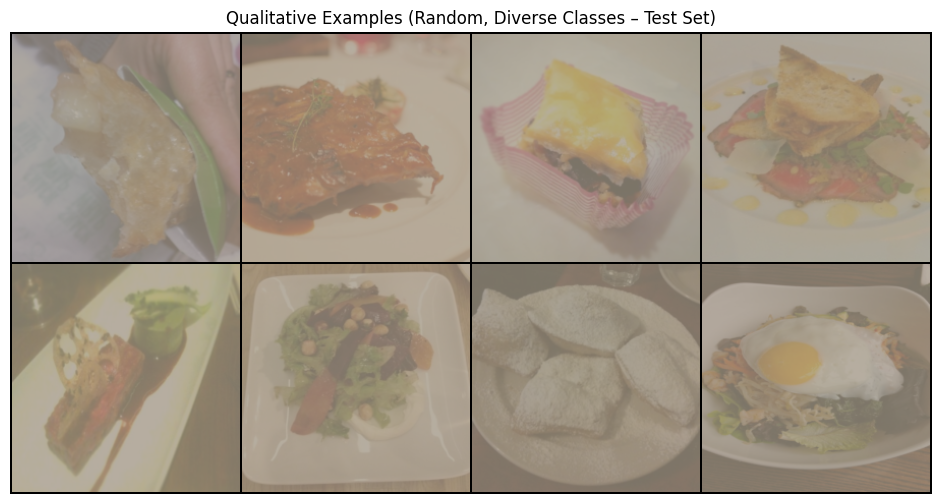

True class: apple_pie | Pred class: samosa
Pred nutr: {'calories': 246.24620056152344, 'protein': 8.158924102783203, 'fat': 10.620960235595703, 'carbs': 25.811481475830078, 'sugars': 5.405580043792725, 'sodium': 345.7589111328125}
GT   nutr: {'calories': 300.0, 'protein': 3.0333328247070312, 'fat': 12.033333778381348, 'carbs': 45.06666564941406, 'sugars': 20.0, 'sodium': 150.0}
True class: baby_back_ribs | Pred class: peking_duck
Pred nutr: {'calories': 295.3142395019531, 'protein': 18.556854248046875, 'fat': 18.159435272216797, 'carbs': 11.470806121826172, 'sugars': 5.899694442749023, 'sodium': 289.1522216796875}
GT   nutr: {'calories': 360.0, 'protein': 25.135238647460938, 'fat': 22.0, 'carbs': 10.0, 'sugars': 8.0, 'sodium': 480.0}
True class: baklava | Pred class: baklava
Pred nutr: {'calories': 334.9074401855469, 'protein': 4.306828022003174, 'fat': 15.814107894897461, 'carbs': 42.539791107177734, 'sugars': 26.04132843017578, 'sodium': 172.63824462890625}
GT   nutr: {'calories': 33

In [40]:
# ============================================================
# Qualitative Evaluation: Random & Class-Diverse Test Samples
# ------------------------------------------------------------
# This section visualizes model predictions on randomly selected
# test images, enforcing class diversity to avoid batch bias.
#
# For each example, we show:
# - the input image
# - true vs predicted class
# - predicted vs ground-truth nutrition (per 100g)
# ============================================================


import random
import torchvision
import matplotlib.pyplot as plt

def denorm_for_display(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    x = x.cpu() * std + mean
    return torch.clamp(x, 0, 1)

model.eval()

# -------------------------------------------------------
# Collect a pool of random samples across test set
# -------------------------------------------------------
samples = []
used_classes = set()
target_k = 8

with torch.no_grad():
    for images, labels, nutr_norm_gt in test_loader:
        images = images.to(device)
        logits, nutr_norm_pred = model(images)
        preds = logits.argmax(dim=1)

        for i in range(images.size(0)):
            cls = int(labels[i])
            if cls not in used_classes:
                samples.append({
                    "image": images[i].cpu(),
                    "true": cls,
                    "pred": int(preds[i].cpu()),
                    "nutr_gt": nutr_norm_gt[i].cpu(),
                    "nutr_pred": nutr_norm_pred[i].cpu()
                })
                used_classes.add(cls)

            if len(samples) >= target_k:
                break
        if len(samples) >= target_k:
            break

# -------------------------------------------------------
# Plot image grid
# -------------------------------------------------------
imgs = torch.stack([s["image"] for s in samples])
grid = torchvision.utils.make_grid(denorm_for_display(imgs), nrow=4)

plt.figure(figsize=(12,6))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Qualitative Examples (Random, Diverse Classes – Test Set)")
plt.show()

# -------------------------------------------------------
# Print detailed predictions
# -------------------------------------------------------
for s in samples:
    nutr_p = unnormalize_nutr(s["nutr_pred"], y_mean.cpu(), y_std.cpu())
    nutr_t = unnormalize_nutr(s["nutr_gt"],   y_mean.cpu(), y_std.cpu())

    print("="*70)
    print(f"True class: {classes[s['true']]} | Pred class: {classes[s['pred']]}")
    print("Pred nutr:", {k: float(v) for k,v in zip(TARGET_COLS, nutr_p.numpy())})
    print("GT   nutr:", {k: float(v) for k,v in zip(TARGET_COLS, nutr_t.numpy())})



# Single-Sample Prediction Demo

In [21]:
# ============================================================
# Single-Sample Prediction Demo (Example 1)
# ------------------------------------------------------------
# Demonstrates model output on an individual test image.
# Useful for sanity checking predictions and inspecting
# nutrition outputs in detail.
# ============================================================
import torch

model.eval()

# grab one batch from test loader
images, labels, nutr_norm_gt = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    logits, nutr_norm_pred = model(images)

pred_idx = logits.argmax(dim=1).cpu()
true_idx = labels.cpu()

# take the first example in batch
i = 0
pred_class = classes[int(pred_idx[i])]
true_class = classes[int(true_idx[i])]

nutr_pred = unnormalize_nutr(nutr_norm_pred[i].cpu(), y_mean.cpu(), y_std.cpu())
nutr_gt   = unnormalize_nutr(nutr_norm_gt[i].cpu(),   y_mean.cpu(), y_std.cpu())

print("Pred class:", pred_class)
print("True class:", true_class)
print("Pred nutrition per 100g:", format_nutr(nutr_pred))
print("GT nutrition per 100g:",   format_nutr(nutr_gt))


Pred class: samosa
True class: apple_pie
Pred nutrition per 100g: {'calories': 246.24620056152344, 'protein': 8.158924102783203, 'fat': 10.620960235595703, 'carbs': 25.811481475830078, 'sugars': 5.405580043792725, 'sodium': 345.7589111328125}
GT nutrition per 100g: {'calories': 300.0, 'protein': 3.0333328247070312, 'fat': 12.033333778381348, 'carbs': 45.06666564941406, 'sugars': 20.0, 'sodium': 150.0}


In [28]:
# ============================================================
# Single-Sample Prediction Demo (Example 2)
# ------------------------------------------------------------
# Shows another example from a different index in the batch
# to highlight variability in predictions.
# ============================================================
import torch

model.eval()

# grab one batch from test loader
images, labels, nutr_norm_gt = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    logits, nutr_norm_pred = model(images)

pred_idx = logits.argmax(dim=1).cpu()
true_idx = labels.cpu()

# take the first example in batch
i = 5
pred_class = classes[int(pred_idx[i])]
true_class = classes[int(true_idx[i])]

nutr_pred = unnormalize_nutr(nutr_norm_pred[i].cpu(), y_mean.cpu(), y_std.cpu())
nutr_gt   = unnormalize_nutr(nutr_norm_gt[i].cpu(),   y_mean.cpu(), y_std.cpu())

print("Pred class:", pred_class)
print("True class:", true_class)
print("Pred nutrition per 100g:", format_nutr(nutr_pred))
print("GT nutrition per 100g:",   format_nutr(nutr_gt))


Pred class: apple_pie
True class: apple_pie
Pred nutrition per 100g: {'calories': 221.5882568359375, 'protein': 7.077958106994629, 'fat': 9.296356201171875, 'carbs': 26.902084350585938, 'sugars': 8.212603569030762, 'sodium': 259.90277099609375}
GT nutrition per 100g: {'calories': 300.0, 'protein': 3.0333328247070312, 'fat': 12.033333778381348, 'carbs': 45.06666564941406, 'sugars': 20.0, 'sodium': 150.0}


# Creative Feature: Class Prototype Construction (Embedding Space)

In [30]:
import torch
import torch.nn.functional as F
from collections import defaultdict
import numpy as np

model.eval()

@torch.no_grad()
def build_class_prototypes(loader, classes, device, max_imgs_per_class=80):
    """
    Build one prototype embedding per class by averaging backbone embeddings.
    Uses up to max_imgs_per_class images per class for speed.
    Returns:
      prototypes: [C, D] tensor (L2-normalized)
      counts: [C] numpy array counts used
    """
    C = len(classes)
    sums = None
    counts = np.zeros(C, dtype=np.int32)

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        feats = model.backbone(images)        # [B, 512]
        feats = F.normalize(feats, dim=1)     # normalize for cosine similarity

        if sums is None:
            D = feats.shape[1]
            sums = torch.zeros((C, D), device=device)

        for i in range(feats.size(0)):
            c = int(labels[i].item())
            if counts[c] < max_imgs_per_class:
                sums[c] += feats[i]
                counts[c] += 1

        # stop early if we collected enough for every class
        if (counts >= max_imgs_per_class).all():
            break

    # avoid division by zero
    prototypes = sums / torch.tensor(np.maximum(counts, 1)[:, None], device=device)
    prototypes = F.normalize(prototypes, dim=1)
    return prototypes.detach().cpu(), counts

# Use TRAIN loader for prototypes (more variety)
prototypes, proto_counts = build_class_prototypes(train_loader, classes, device, max_imgs_per_class=80)
print("prototypes shape:", prototypes.shape)
print("min/max samples per class used:", proto_counts.min(), proto_counts.max())


prototypes shape: torch.Size([101, 512])
min/max samples per class used: 80 80


# Calorie Vector per Class (for Recommendation Logic)

In [31]:
# ============================================================
# Calorie Reference Vector
# ------------------------------------------------------------
# Stores calorie values (per 100g) for each Food-101 class
# in class-index order. Used to filter lower-calorie alternatives
# during similarity-based recommendation.
# ============================================================

# Calories per 100g in Food-101 class order
# (Assumes index 0 in nutrition vector corresponds to calories)
calories_per100 = torch.tensor([float(nutrition_mapping[c][0]) for c in classes])  # assumes index 0 is calories
print("Calories vector shape:", calories_per100.shape)
print("Example:", classes[0], calories_per100[0].item())


Calories vector shape: torch.Size([101])
Example: apple_pie 300.0


# Creative Feature: Similarity-Based Lower-Calorie Suggestions (Embedding Space)

In [32]:
# ============================================================
# Creative Feature: Suggest Visually Similar Lower-Calorie Foods
# ------------------------------------------------------------
# Given a query food image, this function:
# 1) Extracts its embedding using the model backbone
# 2) Finds visually similar food classes via cosine similarity
# 3) Filters candidates that have lower calories per 100g
#
# This demonstrates a practical, health-oriented application
# beyond standard classification/regression.
# ============================================================

import torch
import torch.nn.functional as F

@torch.no_grad()
def suggest_similar_lower_calorie(
    image_tensor,                    # [3, 224, 224], already preprocessed
    prototypes,                      # [C, D] class prototype embeddings (CPU)
    calories_per100,                 # [C] calorie values per class (CPU)
    classes,
    device,
    topk_sim=15,                     # number of visually similar classes to consider
    topk_out=5,                      # number of final suggestions to return
    min_calorie_drop=20.0            # minimum calorie reduction (kcal/100g)
):
    """
    Suggest visually similar food classes with lower calorie density.

    The query image is embedded using the model backbone, compared
    against class prototypes using cosine similarity, and filtered
    based on calorie reduction.
    """
    model.eval()

    # Extract normalized embedding for query image
    x = image_tensor.unsqueeze(0).to(device)
    emb = model.backbone(x)                  # [1, D]
    emb = F.normalize(emb, dim=1).cpu()      # normalize for cosine similarity

    # Cosine similarity with all class prototypes
    sims = (prototypes @ emb.squeeze(0))     # [C]

    # Predicted class based on nearest prototype (embedding space)
    pred_idx = int(torch.argmax(sims).item())
    pred_class = classes[pred_idx]
    pred_cal = float(calories_per100[pred_idx].item())

    # Retrieve top visually similar candidate classes
    top_sim_idx = torch.topk(sims, k=topk_sim).indices.tolist()

    suggestions = []
    for j in top_sim_idx:
        if j == pred_idx:
            continue

        cal = float(calories_per100[j].item())

        # Only keep candidates with sufficiently lower calories
        if cal <= pred_cal - min_calorie_drop:
            suggestions.append({
                "class": classes[j],
                "similarity": float(sims[j].item()),
                "calories_per_100g": cal,
                "calorie_drop": pred_cal - cal
            })

        if len(suggestions) >= topk_out:
            break

    return {
        "pred_class": pred_class,
        "pred_calories_per_100g": pred_cal,
        "suggestions": suggestions
    }


# Demo: Lower-Calorie Suggestions for a Test Image

Predicted class (by embedding nearest): samosa
Pred calories per 100g: 300.0

Visually similar but lower-calorie alternatives:
- grilled_cheese_sandwich   sim=0.807  cal=266.6  drop=33.4
- gyoza                     sim=0.765  cal=200.0  drop=100.0
- spring_rolls              sim=0.745  cal=200.0  drop=100.0
- french_toast              sim=0.728  cal=250.0  drop=50.0
- fish_and_chips            sim=0.726  cal=250.0  drop=50.0
- grilled_salmon            sim=0.701  cal=200.0  drop=100.0


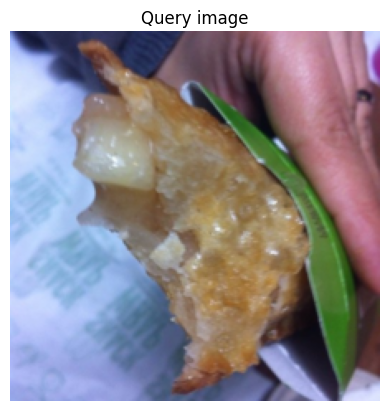

In [33]:
import matplotlib.pyplot as plt

# grab 1 example from test set
img, label, nutr_norm = test_ds[0]   # you can change index
result = suggest_similar_lower_calorie(
    image_tensor=img,
    prototypes=prototypes,
    calories_per100=calories_per100,
    classes=classes,
    device=device,
    topk_sim=20,
    topk_out=6,
    min_calorie_drop=15.0
)

print("Predicted class (by embedding nearest):", result["pred_class"])
print("Pred calories per 100g:", result["pred_calories_per_100g"])
print("\nVisually similar but lower-calorie alternatives:")
for s in result["suggestions"]:
    print(f"- {s['class']:25s} sim={s['similarity']:.3f}  cal={s['calories_per_100g']:.1f}  drop={s['calorie_drop']:.1f}")

# show image
plt.figure()
plt.imshow(img.permute(1,2,0).cpu().numpy())
plt.axis("off")
plt.title("Query image")
plt.show()


# Demo: End-to-End Prediction + Recommendation

In [34]:
# ============================================================
# Demo: End-to-End Prediction + Recommendation
# ------------------------------------------------------------
# Shows how the full pipeline behaves on a test image.
# ============================================================
@torch.no_grad()
def predict_class_and_suggest_alternatives(
    image_tensor,
    prototypes,
    calories_per100,
    classes,
    device,
    topk_sim=30,
    topk_out=6,
    min_calorie_drop=20.0
):
    model.eval()
    x = image_tensor.unsqueeze(0).to(device)

    logits, nutr_pred_norm = model(x)
    pred_idx = int(torch.argmax(logits, dim=1).item())
    pred_class = classes[pred_idx]
    pred_cal = float(calories_per100[pred_idx].item())

    emb = model.backbone(x)
    emb = F.normalize(emb, dim=1).cpu()
    sims = (prototypes @ emb.squeeze(0))

    top_sim_idx = torch.topk(sims, k=topk_sim).indices.tolist()

    suggestions = []
    for j in top_sim_idx:
        if j == pred_idx:
            continue
        cal = float(calories_per100[j].item())
        if cal <= pred_cal - min_calorie_drop:
            suggestions.append((classes[j], float(sims[j].item()), cal, pred_cal - cal))
        if len(suggestions) >= topk_out:
            break

    return pred_class, pred_cal, suggestions

img, label, _ = test_ds[10]
pred_class, pred_cal, sugg = predict_class_and_suggest_alternatives(
    img, prototypes, calories_per100, classes, device,
    topk_sim=30, topk_out=8, min_calorie_drop=15.0
)

print("Model predicted:", pred_class, "| calories/100g:", pred_cal)
print("Alternatives (visually similar + lower calories):")
for name, sim, cal, drop in sugg:
    print(f"- {name:25s} sim={sim:.3f} cal={cal:.1f} drop={drop:.1f}")


Model predicted: apple_pie | calories/100g: 300.0
Alternatives (visually similar + lower calories):
- grilled_cheese_sandwich   sim=0.761 cal=266.6 drop=33.4
- bread_pudding             sim=0.738 cal=250.0 drop=50.0
- pizza                     sim=0.729 cal=250.0 drop=50.0
- ice_cream                 sim=0.702 cal=200.0 drop=100.0
- croque_madame             sim=0.694 cal=225.1 drop=74.9
- hot_dog                   sim=0.691 cal=250.0 drop=50.0
- french_toast              sim=0.683 cal=250.0 drop=50.0
- pancakes                  sim=0.666 cal=250.0 drop=50.0
